In [7]:
# %%
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from skimage import io, color, feature
from skimage.transform import resize
# 单独拆分导入，确保函数被正确识别
from skimage.feature import graycomatrix, graycoprops,hog
from PIL import Image  # 改用PIL读取图片，更稳健处理调色板/透明通道
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')  # 屏蔽PIL调色板警告
 
# 解决matplotlib中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']  # 'SimHei' 是黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号'-'显示为方块的问题
 
# Scikit-learn 相关导入
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
 
# 模型导入
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
 
 
from skimage import io, color, feature
 
print("所有库导入成功！")
print(f"特征提取将使用 scikit-image 库。")


 


所有库导入成功！
特征提取将使用 scikit-image 库。


成功找到 7 个类别: ['apple', 'banana', 'grapes', 'kiwi', 'lemon', 'mango', 'watermelon']


,类别,图片数量
0,apple,68
1,banana,75
2,grapes,100
3,kiwi,88
4,lemon,82
5,mango,86
6,watermelon,84


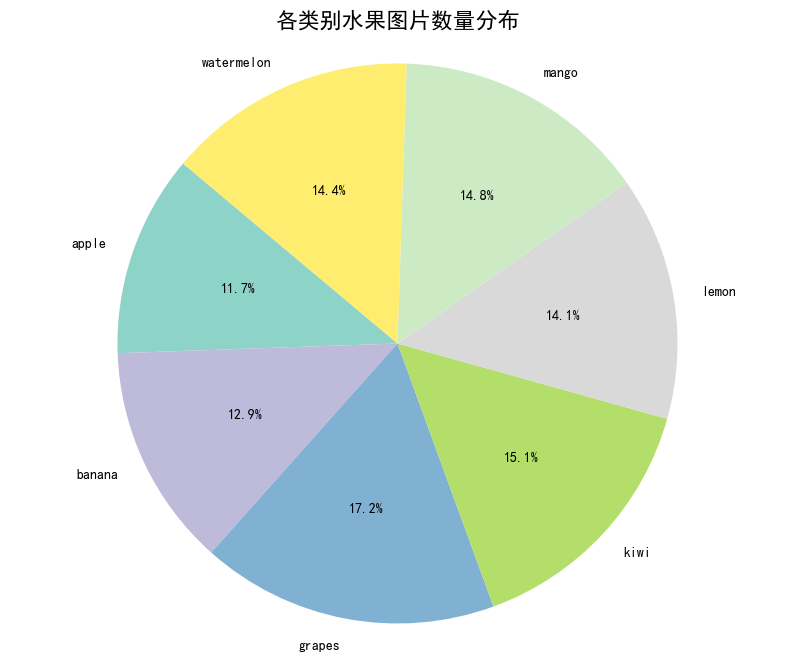

In [8]:
# 定义数据路径
DATA_DIR = 'C:\\tjl-nnu\\2025-2026-1\\机器学习\\水果分类\\data'
 
 
try:
    categories = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
    categories.sort()
    if not categories:
        raise FileNotFoundError
    print(f"成功找到 {len(categories)} 个类别: {categories}")
except FileNotFoundError:
    print(f"错误：在当前目录下未找到 '{DATA_DIR}' 文件夹或其为空。请确保您的数据文件夹结构正确。")
    categories = ['apple', 'banana', 'grapes', 'kiwi', 'lemon', 'mango', 'watermelon']
 
class_counts = {}
for category in categories:
    class_path = os.path.join(DATA_DIR, category)
    image_files = []
    for ext in ('*.png', '*.jpg', '*.jpeg', '*.bmp', '*.gif'):
        image_files.extend(glob.glob(os.path.join(class_path, ext)))
    class_counts[category] = len(image_files)
 
# 将统计结果转换为DataFrame方便可视化
count_df = pd.DataFrame(list(class_counts.items()), columns=['类别', '图片数量'])
display(count_df)
 
# --- 可视化：绘制每个类别图片数量的饼状图 ---
plt.figure(figsize=(10, 8))
colors = plt.cm.Set3(np.linspace(0, 1, len(categories)))
plt.pie(count_df['图片数量'], labels=count_df['类别'], autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('各类别水果图片数量分布', fontsize=16)
plt.axis('equal')  # 保证饼图是圆形
plt.show()
 
 


In [28]:
# 特征提取参数（固定）
COLOR_BINS = 24
BLOCK_SIZE = (2, 2)
LBP_PARAMS = [(32, 4), (16, 2)]
GLCM_DISTANCES = [1, 2, 3, 4]
GLCM_ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]
GLCM_PROPS = ['contrast', 'correlation', 'energy', 'homogeneity']
HOG_ORIENTATIONS = 12
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)
IMG_SIZE = (224, 224)
# PCA降维参数（保留95%的信息）
PCA_VARIANCE_RATIO = 0.95

# 预计算各部分固定维度
color_dim = BLOCK_SIZE[0] * BLOCK_SIZE[1] * 2 * 3 * COLOR_BINS
lbp_dim = sum([p + 2 for p, _ in LBP_PARAMS])
glcm_dim = BLOCK_SIZE[0] * BLOCK_SIZE[1] * len(GLCM_DISTANCES) * len(GLCM_ANGLES) * len(GLCM_PROPS)
# 预计算HOG固定维度
#hog_dummy_gray = np.zeros(IMG_SIZE, dtype=np.uint8)
#hog_fixed_dim = hog(
  #  hog_dummy_gray, orientations=HOG_ORIENTATIONS,
   # pixels_per_cell=HOG_PIXELS_PER_CELL, cells_per_block=HOG_CELLS_PER_BLOCK,
   # block_norm='L2-Hys', transform_sqrt=True, feature_vector=True
#).shape[0]
total_raw_dim = color_dim + lbp_dim + glcm_dim 

print(f"开始提取增强型手工特征（原始总维度：{total_raw_dim}维）...")
print(f"特征维度拆解：")
print(f"  - 分块RGB+HSV颜色：{color_dim}维")
print(f"  - 双尺度Uniform LBP：{lbp_dim}维")
print(f"  - 分块GLCM纹理：{glcm_dim}维")
print(f"  - HOG形状特征：{hog_fixed_dim}维")
print(f"  - 原始总维度：{total_raw_dim}维")


开始提取增强型手工特征（原始总维度：884维）...
特征维度拆解：
  - 分块RGB+HSV颜色：576维
  - 双尺度Uniform LBP：52维
  - 分块GLCM纹理：256维
  - HOG形状特征：34992维
  - 原始总维度：884维


In [29]:
# 假设categories和DATA_DIR已提前定义（保持原有逻辑）
# categories = ["类别1", "类别2", ...]  # 需用户根据实际数据修改
# DATA_DIR = "数据文件夹路径"  # 需用户根据实际路径修改

features = []
labels = []
error_count = 0
# 遍历所有图片提取原始特征
for category in categories:
    class_path = os.path.join(DATA_DIR, category)
    image_files = []
    for ext in ('*.png', '*.jpg', '*.jpeg', '*.bmp', '*.gif'):
        image_files.extend(glob.glob(os.path.join(class_path, ext)))

    for img_path in image_files:
        try:
            # 1. PIL读取并强制转为RGB
            with Image.open(img_path) as pil_img:
                pil_img = pil_img.convert('RGB')
                img = np.array(pil_img)

            # 2. 固定缩放至224×224
            img = resize(img, IMG_SIZE, anti_aliasing=True)
            img = (img * 255).astype(np.uint8)
            if img.ndim != 3 or img.shape[-1] != 3:
                raise ValueError("图像通道数非3")

            # 3. 分块颜色特征
            color_features = []
            h, w = IMG_SIZE
            block_h = h // BLOCK_SIZE[0]
            block_w = w // BLOCK_SIZE[1]
            for i in range(BLOCK_SIZE[0]):
                for j in range(BLOCK_SIZE[1]):
                    block = img[i*block_h:(i+1)*block_h, j*block_w:(j+1)*block_w]
                    block_hsv = color.rgb2hsv(block)
                    hist_r = np.histogram(block[:, :, 0], bins=COLOR_BINS, range=(0, 255))[0]
                    hist_g = np.histogram(block[:, :, 1], bins=COLOR_BINS, range=(0, 255))[0]
                    hist_b = np.histogram(block[:, :, 2], bins=COLOR_BINS, range=(0, 255))[0]
                    hist_h = np.histogram(block_hsv[:, :, 0], bins=COLOR_BINS, range=(0, 1))[0]
                    hist_s = np.histogram(block_hsv[:, :, 1], bins=COLOR_BINS, range=(0, 1))[0]
                    hist_v = np.histogram(block_hsv[:, :, 2], bins=COLOR_BINS, range=(0, 1))[0]
                    color_features.extend([hist_r, hist_g, hist_b, hist_h, hist_s, hist_v])
            color_features = np.concatenate(color_features)
            if len(color_features) != color_dim:
                raise ValueError(f"颜色特征维度异常")

            # 4. 多尺度LBP特征
            img_gray = (color.rgb2gray(img) * 255).astype(np.uint8)
            lbp_features = []
            for P, R in LBP_PARAMS:
                lbp = feature.local_binary_pattern(img_gray, P=P, R=R, method="uniform")
                lbp_hist = np.histogram(lbp.ravel(), bins=np.arange(0, P+3), range=(0, P+2))[0]
                lbp_hist = lbp_hist / (lbp_hist.sum() + 1e-7)
                lbp_features.append(lbp_hist)
            lbp_features = np.concatenate(lbp_features)
            if len(lbp_features) != lbp_dim:
                raise ValueError(f"LBP特征维度异常")

            # 5. 分块GLCM特征
            glcm_features = []
            for i in range(BLOCK_SIZE[0]):
                for j in range(BLOCK_SIZE[1]):
                    block_gray = img_gray[i*block_h:(i+1)*block_h, j*block_w:(j+1)*block_w]
                    glcm = graycomatrix(
                        block_gray, distances=GLCM_DISTANCES, angles=GLCM_ANGLES,
                        levels=256, symmetric=True, normed=True
                    )
                    for prop in GLCM_PROPS:
                        glcm_prop = graycoprops(glcm, prop).flatten()
                        glcm_features.extend(glcm_prop)
            glcm_features = np.array(glcm_features)
            if len(glcm_features) != glcm_dim:
                raise ValueError(f"GLCM特征维度异常")

            # 6. HOG特征
           # hog_features = hog(
             #   img_gray, orientations=HOG_ORIENTATIONS,
             #   pixels_per_cell=HOG_PIXELS_PER_CELL, cells_per_block=HOG_CELLS_PER_BLOCK,
             #   block_norm='L2-Hys', transform_sqrt=True, feature_vector=True
           # )
           # if len(hog_features) != hog_fixed_dim:
              #  raise ValueError(f"HOG特征维度异常")

            # 7. 特征归一化
            #color_features = color_features / (np.linalg.norm(color_features) + 1e-7)
            #lbp_features = lbp_features / (np.linalg.norm(lbp_features) + 1e-7)
            #glcm_features = glcm_features / (np.linalg.norm(glcm_features) + 1e-7)
            #hog_features = hog_features / (np.linalg.norm(hog_features) + 1e-7)

            #8. 拼接总特征
            feature_vector = np.concatenate([color_features, lbp_features, glcm_features])
            features.append(feature_vector)
            labels.append(category)

        except Exception as e:
            error_count += 1
            if error_count <= 20:
                print(f"处理图片 {img_path} 时出错: {str(e)[:80]}")
            continue

if not features:
    raise ValueError("没有成功提取任何特征")

# 转换为numpy数组
X = np.array(features)
y = np.array(labels)





In [30]:
# 将文本标签转换为数字
le = LabelEncoder()
y_encoded = le.fit_transform(y)
 
# 划分训练集和测试集 (80% 训练, 20% 测试)
# stratify=y_encoded 确保训练集和测试集中各个类别的比例与原始数据集相同
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("训练集:", X_train.shape)
print("测试集:", X_test.shape)
 


训练集: (466, 884)
测试集: (117, 884)


In [33]:
#分特征标准化
print("开始分特征标准化...")
from sklearn.preprocessing import StandardScaler

idx1 = color_dim
idx2 = idx1 + lbp_dim
idx3 = idx2 + glcm_dim

def split_features(X):
    X_color = X[:, :idx1]
    X_lbp   = X[:, idx1:idx2]
    X_glcm  = X[:, idx2:idx3]
    X_hog   = X[:, idx3:]
    return X_color, X_lbp, X_glcm, X_hog

Xc_tr, Xl_tr, Xg_tr, Xh_tr = split_features(X_train)
Xc_te, Xl_te, Xg_te, Xh_te = split_features(X_test)

sc_color = StandardScaler().fit(Xc_tr)
sc_lbp   = StandardScaler().fit(Xl_tr)
sc_glcm  = StandardScaler().fit(Xg_tr)
#sc_hog   = StandardScaler().fit(Xh_tr)

X_train_scaled = np.hstack([
    sc_color.transform(Xc_tr),
    sc_lbp.transform(Xl_tr),
    sc_glcm.transform(Xg_tr)
    #sc_hog.transform(Xh_tr)
])

X_test_scaled = np.hstack([
    sc_color.transform(Xc_te),
    sc_lbp.transform(Xl_te),
    sc_glcm.transform(Xg_te)
   # sc_hog.transform(Xh_te)
])

开始分特征标准化...


In [34]:
from sklearn.decomposition import PCA

pca = PCA(n_components=256, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print("PCA 保留信息:", pca.explained_variance_ratio_.sum())

PCA 保留信息: 0.9925909604356092


In [35]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm = SVC(
    kernel='rbf',
    class_weight='balanced'  # ⭐ 关键改进
)

param_grid = {
    'C': [0.1, 1, 10, 50, 100],
    'gamma': [1e-3, 1e-2, 1e-1, 'scale']
}

grid = GridSearchCV(
    svm,
    param_grid,
    scoring='f1_macro',   # ⭐ 不再只看 accuracy
    cv=cv,
    n_jobs=-1,
    verbose=2
)
 
# 执行网格搜索
print("开始SVM模型的网格搜索...")
grid.fit(X_train_pca, y_train)
 
# 输出最优参数
print(f"SVM最优参数: {grid.best_params_}")
best_svm_params = grid.best_params_
 
# 使用最优参数创建模型并在测试集上评估
best_svm = grid.best_estimator_
y_pred_svm = best_svm.predict(X_test_pca)
 
# 评估指标
print("\n--- SVM 模型评估报告 ---")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))
 
# 存储指标用于后续比较
svm_metrics = {
    '准确率': accuracy_score(y_test, y_pred_svm),
    '精确率': precision_score(y_test, y_pred_svm, average='macro'),
    '召回率': recall_score(y_test, y_pred_svm, average='macro'),
    'F1分数': f1_score(y_test, y_pred_svm, average='macro')
}

开始SVM模型的网格搜索...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
SVM最优参数: {'C': 10, 'gamma': 0.001}

--- SVM 模型评估报告 ---
              precision    recall  f1-score   support

       apple       0.60      0.64      0.62        14
      banana       1.00      0.47      0.64        15
      grapes       0.62      0.90      0.73        20
        kiwi       0.72      0.72      0.72        18
       lemon       0.87      0.81      0.84        16
       mango       0.47      0.47      0.47        17
  watermelon       0.81      0.76      0.79        17

    accuracy                           0.69       117
   macro avg       0.73      0.68      0.69       117
weighted avg       0.72      0.69      0.69       117



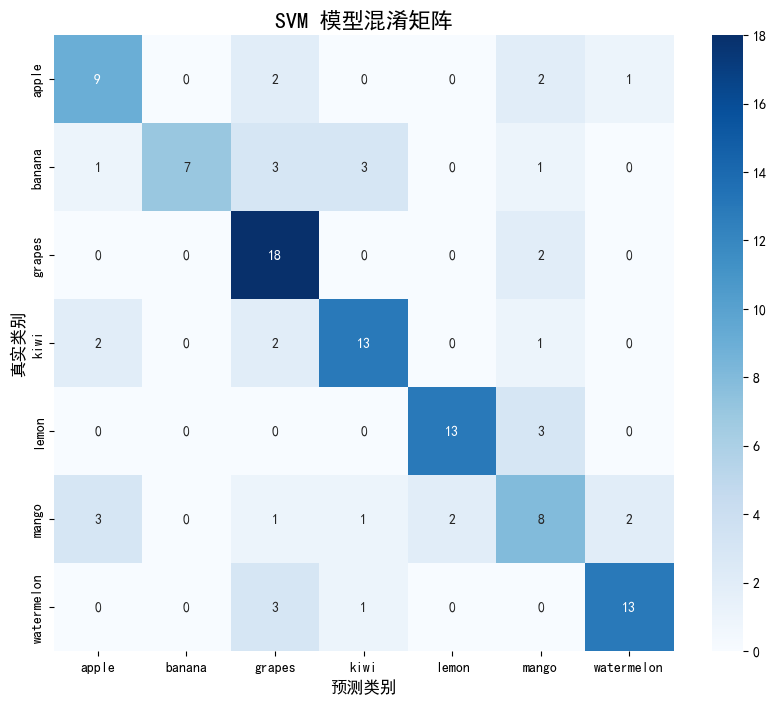

In [36]:

cm_svm = confusion_matrix(y_test, y_pred_svm)
 
plt.figure(figsize=(10, 8))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('SVM 模型混淆矩阵', fontsize=16)
plt.ylabel('真实类别', fontsize=12)
plt.xlabel('预测类别', fontsize=12)
plt.show()
 

